# Asian option variance reduction

Author: Fred J. Hickernell

This companion to the generating-samples notebook compares importance sampling, a European-call control variate, their combination, and randomized low discrepancy points for the same Asian-call price.

Run with the course `qmcpy` kernel, or open a private working copy in Colab:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fjhickernell/MATH565Fall2026/blob/main/notebooks/performance/AsianOptionVarianceReduction.ipynb)

In Colab, run the setup cell once and then continue in order. Save a copy in Drive to keep your changes.

$\newcommand{\vX}{\boldsymbol{X}}$

In [1]:
from pathlib import Path
import shutil
import subprocess
import sys
import time

NOTEBOOK_START_TIME = time.perf_counter()

colab = "google.colab" in sys.modules
if colab:
    print("Setting up this course's recorded classlib, QMCPy, and TeX; this may take several minutes …")
    course_checkout = Path("/content/MATH565Fall2026")
    if not course_checkout.exists():
        subprocess.run(
            [
                "git", "clone", "--quiet", "--depth", "1",
                "https://github.com/fjhickernell/MATH565Fall2026.git",
                str(course_checkout),
            ],
            check=True,
        )
    subprocess.run(
        [
            "git", "-C", str(course_checkout),
            "-c", "submodule.classlib.url=https://github.com/fjhickernell/HickernellAcademicLib.git",
            "-c", "submodule.qmcpy.url=https://github.com/QMCSoftware/qmcpy.git",
            "submodule", "update", "--init", "classlib", "qmcpy",
        ],
        check=True,
    )
    if shutil.which("latex") is None:
        subprocess.run(
            [
                "apt-get", "-qq", "install", "-y",
                "cm-super", "dvipng", "texlive-latex-extra",
                "texlive-latex-recommended",
            ],
            check=True,
        )
    subprocess.run(
        [
            sys.executable, "-m", "pip", "install", "-q",
            str(course_checkout / "classlib"),
            str(course_checkout / "qmcpy"),
        ],
        check=True,
    )
    print("Colab setup complete.")
    print("For faster repeated work, use the local `qmcpy` environment.")

## Asian call and sampling map

Under the risk-neutral geometric Brownian model, $S(t)=S_0\exp\{(r-\sigma^2/2)t+\sigma B(t)\}$. The discounted payoff is $e^{-rT}(d^{-1}\sum_{j=1}^d S(t_j)-K)_+$. QMCPy’s `BrownianMotion` supplies the uniform-to-path map developed in **Generating Samples**. We use its Cholesky construction to retain the chronological-increment interpretation. The variance-reduction methods below change the integrand while preserving its expectation.
Let $\boldsymbol X=(B(t_1),\ldots,B(t_d))\sim\operatorname{Norm}(\boldsymbol0,\mathsf\Sigma)$ be the target Brownian path, with $\Sigma_{jk}=\min(t_j,t_k)$. The function $f$ builds asset prices and returns the discounted Asian payoff, so $Y=f(\boldsymbol X)$ and $\mu=\mathbb E(Y)$.
The monitoring dates are $t_j=jT/d$. The parameter cell uses `d=52` and `T=1` for weekly monitoring over one year; changing `d` changes the discretely monitored contract as well as the sampling dimension.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import qmcpy as qp

%matplotlib inline

S0, K, r, sigma, T, d = 80.0, 100.0, 0.03, 0.7, 1.0, 52
# Change d to explore the monitoring frequency (52 gives weekly dates for T=1).
dt = T/d
times = dt*np.arange(1, d+1)
option_params = dict(start_price=S0, strike_price=K, interest_rate=r,
                     volatility=sigma, t_final=T, decomp_type="Cholesky")

def weighted_payoffs(w, theta=0.0):
    shifted_w = w + theta*times
    stock = S0*np.exp((r-sigma*sigma/2)*times + sigma*shifted_w)
    likelihood = np.exp(-theta*w[..., -1]-theta*theta*T/2)
    asian = np.exp(-r*T)*np.maximum(stock.mean(axis=-1)-K, 0)*likelihood
    european = np.exp(-r*T)*np.maximum(stock[..., -1]-K, 0)*likelihood
    return np.stack([asian, european])

# QMCPy transforms cube points to Brownian paths before evaluating the payoffs.
payoff_integrand = qp.CustomFun(
    qp.BrownianMotion(qp.IIDStdUniform(d), t_final=T, decomp_type="Cholesky"),
    g=weighted_payoffs, dimension_indv=(2,))

def payoffs(u, theta=0.0):
    asian, european = payoff_integrand.f(u, theta=theta)
    return asian, european

european_option = qp.FinancialOption(qp.IIDStdUniform(d),
                                     option="EUROPEAN", **option_params)
european_mean = european_option.get_exact_value()
print(f"Monitoring: {d} equally spaced dates over T={T:g} years")
print(f"Known European-call mean: {european_mean:.6f}")


Monitoring: 52 equally spaced dates over T=1 years
Known European-call mean: 16.578974


## Choose the low discrepancy generator

Sobol' is the default. Set `LD_METHOD` to `"sobol"` for a linearly scrambled and digitally shifted Sobol' sequence, `"lattice"` for a randomly shifted lattice, or `"halton"` for a randomized Halton sequence. Then rerun all cells. Plot labels and replicated comparisons follow the choice; distinct replication seeds supply independent randomizations.

The choice applies to the Asian-call comparison, lookback-call comparison, and price-tolerance stopping rule. Powers of two suit Sobol' and lattice constructions. Halton also accepts other sample sizes; the stopping rule still doubles its sample count at each step.


In [3]:
LD_METHOD = "sobol"  # Choose "sobol", "lattice", or "halton", then rerun all cells.

LD_LABELS = {"sobol": "Randomized Sobol'", "lattice": "Randomized lattice",
             "halton": "Randomized Halton"}
if LD_METHOD not in LD_LABELS:
    raise ValueError('LD_METHOD must be "sobol", "lattice", or "halton".')
LD_LABEL = LD_LABELS[LD_METHOD]


def ld_sampler(dimension, seed=None, replications=None):
    """Create a fresh QMCPy randomization with the selected construction."""
    if LD_METHOD == "sobol":
        return qp.DigitalNetB2(dimension, seed=seed, replications=replications,
                              randomize="LMS DS", order="RADICAL INVERSE")
    if LD_METHOD == "lattice":
        return qp.Lattice(dimension, seed=seed, replications=replications,
                          randomize="SHIFT", order="RADICAL INVERSE")
    # LMS DP supports the independent replications used by the stopping rule.
    return qp.Halton(dimension, seed=seed, replications=replications,
                     randomize="LMS DP")

print("Selected low discrepancy method:", LD_LABEL)


Selected low discrepancy method: Randomized Sobol'


## Importance sampling and a control variate

Choose the drifted proposal $\boldsymbol Z\sim\operatorname{Norm}(\boldsymbol a,\mathsf\Sigma)$, where $a_j=\theta t_j$. Its weight and alternative contribution are
\begin{align*}
w(\boldsymbol z)&=\exp\{-\theta z_d+\theta^2T/2\},\\
g_{\mathrm{IS}}(\boldsymbol z)&=f(\boldsymbol z)w(\boldsymbol z),\qquad
\mathbb E_{\mathrm{prop}}[g_{\mathrm{IS}}(\boldsymbol Z)]=\mu.
\end{align*}
The code constructs $Z(t)=B(t)+\theta t$ from a zero-drift Brownian path. Thus $z_d=B(T)+\theta T$ and the same weight is $\exp\{-\theta B(T)-\theta^2T/2\}$. These are the same likelihood ratio evaluated in two coordinate conventions.

For controls, write $c(\boldsymbol x)$ for the European-call payoff and $\eta_1(\boldsymbol x)=c(\boldsymbol x)-\mathbb E_{\mathrm{tar}}[c(\boldsymbol X)]$. Subtract $\beta\eta_1(\boldsymbol X)$ from $Y$, choosing $\beta$ with a **separate pilot sample**. Under drift, use the weighted European payoff minus its target mean as the zero-mean control. The same likelihood ratio applies to both payoffs.


Here importance sampling uses the identity map with a nonconstant correction $w_T=w$. The inverse-normal/Brownian construction generates the drifted proposal as $\boldsymbol Z=\boldsymbol S_\theta(\boldsymbol U)$; the cube integrand is $h_\theta=g_{\mathrm{IS}}\circ\boldsymbol S_\theta$. With zero drift, this construction is an exact transport to the target: $w_T=1$ and $g_{\mathrm{ET}}=f\circ\boldsymbol S_0$. These roles match Deck 04; the code's `payoffs(u, theta)` returns the composed, weighted contributions on uniform inputs.

In [4]:
pilot=qp.IIDStdUniform(d, seed=2026)(2**14)
def pilot_beta(theta):
    a,c=payoffs(pilot,theta)
    return np.cov(a,c,ddof=1)[0,1]/np.var(c,ddof=1)

for theta in [0.0,1.0]:
    print(f"pilot beta for theta={theta:g}: {pilot_beta(theta):.4f}")

pilot beta for theta=0: 0.3627
pilot beta for theta=1: 0.3151


## Compare independent replications

Each estimate uses the same number of main samples. The empirical standard deviation across replications measures estimator variability; the selected low discrepancy construction is independently randomized across replications.

For each sampler we compare the plain payoff, drift alone, control alone, and drift plus control. IID runs share the same uniform inputs across these four variants within a replication, and the low discrepancy variants share their selected randomized design. Distinct replications use distinct seeds. The pilot-fitted control coefficient is fixed during every main run.

To experiment with drift, change `theta_val` in the next cell and rerun it and the comparison plot. Zero removes the drift. The stopping example has its own `theta_stopping` setting later in the notebook.

In [5]:
n, repetitions=2**14,24
# Play with the importance-sampling drift here, then rerun this cell and its plot.
# theta_val=0 removes the drift; try other values and compare replication SD.
# This setting controls both IID and the selected low discrepancy drift variants.
theta_val = 1.5
methods=[("IID",0.0,False,"iid"),
         ("IID + drift",theta_val,False,"iid"),
         ("IID + control",0.0,True,"iid"),
         ("IID + both",theta_val,True,"iid"),
         (LD_LABEL,0.0,False,"ld"),
         (LD_LABEL + " + drift",theta_val,False,"ld"),
         (LD_LABEL + " + control",0.0,True,"ld"),
         (LD_LABEL + " + both",theta_val,True,"ld")]
results={}
for name,theta,use_cv,design in methods:
    beta=pilot_beta(theta) if use_cv else 0.0
    estimates=[]
    for rep in range(repetitions):
        seed=565+rep
        u=(ld_sampler(d, seed=seed)(n) if design == "ld"
           else qp.IIDStdUniform(d, seed=seed)(n))
        asian,european=payoffs(u,theta)
        estimates.append(np.mean(asian-beta*(european-european_mean)))
    results[name]=np.array(estimates)
print("method                                mean price    replication SD")
for name,values in results.items():
    print(f"{name:37s} {values.mean():10.5f} {values.std(ddof=1):16.5f}")
assert all(np.all(np.isfinite(v)) for v in results.values())

method                                mean price    replication SD
IID                                      7.16813          0.14123
IID + drift                              7.17773          0.07889
IID + control                            7.14699          0.08725
IID + both                               7.17062          0.07646
Randomized Sobol'                        7.16031          0.05170
Randomized Sobol' + drift                7.17286          0.02762
Randomized Sobol' + control              7.14779          0.03922
Randomized Sobol' + both                 7.16955          0.02734


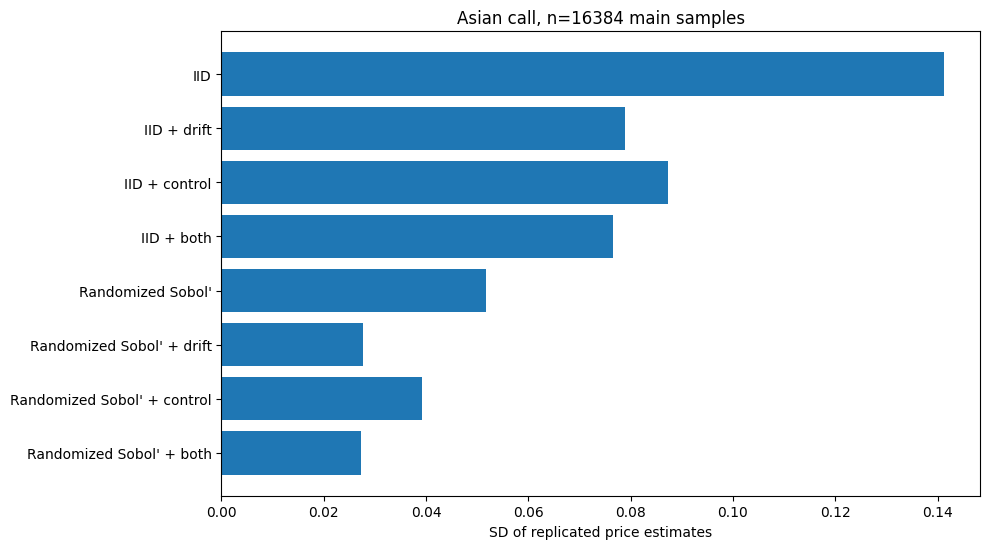

In [6]:
fig,ax=plt.subplots(figsize=(10,5.6))
names=list(results)
sd=[results[name].std(ddof=1) for name in names]
ax.barh(names,sd)
ax.invert_yaxis()
ax.set(xlabel="SD of replicated price estimates",title=f"Asian call, n={n} main samples")
fig.tight_layout()

Drift, a control variate, and randomized low discrepancy sampling address different sources of error. The particular drift and control coefficient can be tuned with a pilot; the performance shown here is for this one option and sample size. The pilot work is additional to the main-sample cost.

## A lookback call on the same paths

A floating-strike lookback call pays $S(T)-\min_{0\le j\le d}S(t_j)$, with $t_0=0$ included. Here the minimum is over the **$d$ monitoring dates and the initial price**, so this is a discretely monitored lookback option. It illustrates a path-dependent payoff without changing the Brownian path generator. The resulting price is for this monitoring schedule; continuous monitoring has a different value.

QMCPy’s `FinancialOption(option="LOOKBACK")` composes the same Cholesky Brownian construction, asset-price map, and discounted payoff. Its minimum includes the initial price. Both the IID samples and the selected randomized low discrepancy samples come from QMCPy.


In [7]:
lookback_option = qp.FinancialOption(qp.IIDStdUniform(d),
                                     option="LOOKBACK", **option_params)

lookback_results = {}
for label in ["IID", LD_LABEL]:
    prices = []
    for rep in range(repetitions):
        seed = 3320+rep
        sampler = (qp.IIDStdUniform(d, seed=seed) if label == "IID"
                   else ld_sampler(d, seed=seed))
        prices.append(lookback_option.f(sampler(n)).mean())
    lookback_results[label] = np.asarray(prices)
for label, prices in lookback_results.items():
    print(f"{label:17s}: lookback price {prices.mean():.5f}, replication SD {prices.std(ddof=1):.5f}")
assert all(np.all(np.isfinite(v)) for v in lookback_results.values())


IID              : lookback price 33.86838, replication SD 0.35739
Randomized Sobol': lookback price 34.06853, replication SD 0.09614


## Stop when the price uncertainty meets a tolerance

Use the existing discounted payoff and a European-call control coefficient fitted on the **separate pilot** above. The coefficient stays fixed throughout the main run. Independent randomizations of the selected low discrepancy construction provide an approximate Student-$t$ interval for the average price. We stop when its reported half-width is at most $\varepsilon$ price units, set by `price_tolerance` below, or the main-sample budget is exhausted. No exact Asian-option price is used.

For the drift $\theta$ chosen by `theta_stopping`, the cube contribution is
\begin{align*}
h_{\theta,\beta}(\boldsymbol u)
&=g_{\mathrm{IS}}(\boldsymbol S_\theta(\boldsymbol u))
-\beta\bigl[c(\boldsymbol S_\theta(\boldsymbol u))w(\boldsymbol S_\theta(\boldsymbol u))
-\mathbb E_{\mathrm{tar}}[c(\boldsymbol X)]\bigr].
\end{align*}
The control has mean zero, so this still estimates the original price. Total work includes the pilot in addition to all 32 main replications. The interval concerns **simulation error for the chosen $d$-date monitoring model**. It does not measure model uncertainty, parameter uncertainty, or error from replacing continuous monitoring with discrete dates.

As in the [Keister stopping comparison](../applications/KeisterExample.ipynb#Practical-stopping-criteria), the replication interval is approximate, and its nominal coverage does not automatically hold after adaptive stopping.

In [8]:
import warnings
from IPython.display import display, Markdown

print("Price stopping method:", LD_LABEL)
price_tolerance = 0.05  # Absolute price uncertainty target; try 0.01.
price_budget = 2**18  # Total main samples across all 32 randomizations.
# Play with the stopping example's drift here, independently of theta_val above.
# Rerun this cell: pilot_beta(theta_stopping) refits the control for that drift.
theta_stopping = 1.0
beta_stopping = pilot_beta(theta_stopping)

def controlled_cube_payoff(u):
    # QMCPy supplies (..., d), including a leading replication axis.
    asian, european = payoffs(u, theta_stopping)
    return asian-beta_stopping*(european-european_mean)

price_integrand = qp.CustomFun(
    qp.Uniform(ld_sampler(d, seed=5650, replications=32)),
    g=controlled_cube_payoff)
price_rule = qp.CubQMCRepStudentT(price_integrand, abs_tol=price_tolerance,
                                rel_tol=0, n_limit=price_budget, alpha=0.01)
with warnings.catch_warnings(record=True) as price_messages:
    warnings.simplefilter("always")
    price_solution, price_data = price_rule.integrate()
price_estimate = float(np.asarray(price_solution).item())
price_low = float(np.asarray(price_data.comb_bound_low).item())
price_high = float(np.asarray(price_data.comb_bound_high).item())
price_radius = max(price_estimate-price_low, price_high-price_estimate)
price_decision = "tolerance met" if price_radius <= price_tolerance else "not met"
pilot_count = len(pilot)
display(Markdown(
    f"| Tolerance | Price estimate | Approximate interval | Radius | Main samples | Pilot samples | Total | Decision |\n"
    f"|--:|--:|:--|--:|--:|--:|--:|:--|\n"
    f"| {price_tolerance:.2f} | {price_estimate:.5f} | [{price_low:.5f}, {price_high:.5f}] | "
    f"{price_radius:.5f} | {int(price_data.n_total):,} | {pilot_count:,} | "
    f"{int(price_data.n_total)+pilot_count:,} | {price_decision} |"))
for message in price_messages:
    print(f"{message.category.__name__}: {str(message.message).strip()}")
assert np.isfinite(price_estimate) and price_low <= price_estimate <= price_high
assert int(price_data.n_total) == 32*int(np.asarray(price_data.n_rep).item())


Price stopping method: Randomized Sobol'


| Tolerance | Price estimate | Approximate interval | Radius | Main samples | Pilot samples | Total | Decision |
|--:|--:|:--|--:|--:|--:|--:|:--|
| 0.05 | 7.16682 | [7.12989, 7.20376] | 0.03693 | 65,536 | 16,384 | 81,920 | tolerance met |

**Explore:** request `price_tolerance = 0.01`, or reduce `price_budget`, and compare the reported decision and total work. A budget stop is not evidence that the tolerance was met. The fitted pilot is additional work; rerunning with new pilot data changes the coefficient and can change efficiency.

In [9]:
notebook_elapsed = time.perf_counter() - NOTEBOOK_START_TIME
notebook_minutes, notebook_seconds = divmod(notebook_elapsed, 60)
print(
    "Total execution time for this notebook is "
    f"{int(notebook_minutes)} min {notebook_seconds:.1f} sec."
)

Total execution time for this notebook is 0 min 6.8 sec.
